# Notebook 01 <> Analyse Exploratoire et Prétraitement (EDA)
## Système de Recommandation Hybride Emploi-Compétences qu Cameroun
**NGOULOU-NGOUBILI Irch Defluviaire  ISE  Data Science & Marketing**

---
### Plan du notebook
1. Chargement et audit des donnÃ©es brutes
2. Analyse des offres d'emploi
3. Analyse des demandeurs d'emploi
4. Analyse des référentiels (MEPC, NCF, ESCO)
5. Exécution du pipeline ETL
6. Validation des données traitées et analyse des paires fine-tuning
7. Visualisations synthétiques


## 1. Chargement et audit des données brutes

In [1]:
import sys, os, json, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

# Chemins projet
ROOT = Path.cwd().resolve()
if not (ROOT / 'config.py').exists():
    ROOT = ROOT.parent

DATA_RAW  = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
DATA_FT   = ROOT / 'data' / 'finetune'
SRC_ETL   = ROOT / 'src' / '01_etl'
SCRIPTS   = ROOT / 'scripts'

for path in (ROOT, SRC_ETL, SCRIPTS):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print("ROOT    :", ROOT)
print("DATA_RAW:", DATA_RAW)
print("Fichiers disponibles:")
for f in sorted(DATA_RAW.iterdir()): print("  ", f.name)


ROOT    : D:\DATA SCIENCES\SYSTEME-DE-RECOMMANDATION-HYBRIDE-
DATA_RAW: D:\DATA SCIENCES\SYSTEME-DE-RECOMMANDATION-HYBRIDE-\data\raw
Fichiers disponibles:
   data_processed.xlsx
   demandeur.xlsx
   esco
   MEPC_Nomenclature_Camerounaise_Metiers.xlsx
   NCF_Nomenclature_Camerounaise_Formations.xlsx
   offres.xlsx
   offres_fusionnees_preprocessed.xlsx
   ~$offres.xlsx
   ~$offres_fusionnees_preprocessed.xlsx


In [2]:
df_offres = pd.read_excel(DATA_RAW / 'offres_fusionnees_preprocessed.xlsx', dtype=str, sheet_name="data")
df_cand   = pd.read_excel(DATA_RAW / 'demandeur.xlsx')
mepc_raw  = pd.read_excel(DATA_RAW / 'MEPC_Nomenclature_Camerounaise_Metiers.xlsx', sheet_name=None)
ncf_raw   = pd.read_excel(DATA_RAW / 'NCF_Nomenclature_Camerounaise_Formations.xlsx', sheet_name=None)

print(f"Offres    : {df_offres.shape[0]:,} lignes Ã— {df_offres.shape[1]} colonnes")
print(f"Candidats : {df_cand.shape[0]:,} lignes Ã— {df_cand.shape[1]} colonnes")
print(f"MEPC      : {list(mepc_raw.keys())}")
print(f"NCF       : {list(ncf_raw.keys())}")


Offres    : 9,127 lignes Ã— 23 colonnes
Candidats : 1,105 lignes Ã— 14 colonnes
MEPC      : ['Grands Groupes', 'Sous-Groupes', 'Groupes de Base']
NCF       : ['Niveaux de Formation', 'Grands Domaines', 'Domaines Spécialisés', 'Domaines Détaillés']


## 2. Analyse des offres d'emploi

### Rapport de qualitÃ© (taux de remplissage)

In [3]:
rapport_offres = pd.DataFrame({
    'Colonne': df_offres.columns,
    'Non nuls': [df_offres[c].notna().sum() for c in df_offres.columns],
    'Remplissage (%)': [round(df_offres[c].notna().mean()*100, 1) for c in df_offres.columns],
    'Uniques': [df_offres[c].nunique() for c in df_offres.columns],
})
rapport_offres.style.background_gradient(subset=['Remplissage (%)'], cmap='RdYlGn')


,Colonne,Non nuls,Remplissage (%),Uniques
0,id_offre,9127,100.000000,9127
1,titre_original,9126,100.000000,7509
2,titre_normalise,9126,100.000000,7135
3,secteur_activite,9127,100.000000,17
4,entreprise,3912,42.900000,872
5,type_entreprise,2388,26.200000,3
6,ville_region,9126,100.000000,255
7,pays,9127,100.000000,2
8,groupe_contrat,2388,26.200000,4
9,type_contrat,9127,100.000000,15


### Doublons

In [5]:
n_dup = df_offres.duplicated().sum()
print(f"Doublons exacts     : {n_dup:,} ({n_dup/len(df_offres)*100:.1f}%)")
print(f"Après dédoublonnage : {len(df_offres) - n_dup:,} offres uniques")

# Champ Détails de l'Annonce à bruit
details_ok = df_offres["description_poste"].notna()
print(f"\nDétails de l'Annonce remplis : {details_ok.sum():,} ({details_ok.mean()*100:.1f}%)")
print(f"Longueur moyenne (chars)     : {df_offres['description_poste'].dropna().str.len().mean():.0f}")


Doublons exacts     : 0 (0.0%)
Après dédoublonnage : 9,127 offres uniques

Détails de l'Annonce remplis : 9,127 (100.0%)
Longueur moyenne (chars)     : 793


### Distribution

In [6]:
df_offres.columns

Index(['id_offre', 'titre_original', 'titre_normalise', 'secteur_activite',
       'entreprise', 'type_entreprise', 'ville_region', 'pays',
       'groupe_contrat', 'type_contrat', 'exp_min_annees', 'exp_max_annees',
       'niveau_etude', 'competences_cles', 'description_poste', 'missions',
       'profil_requis', 'info_employeur', 'source', 'lien_job',
       'date_publication', 'mois', 'trimestre'],
      dtype='str')

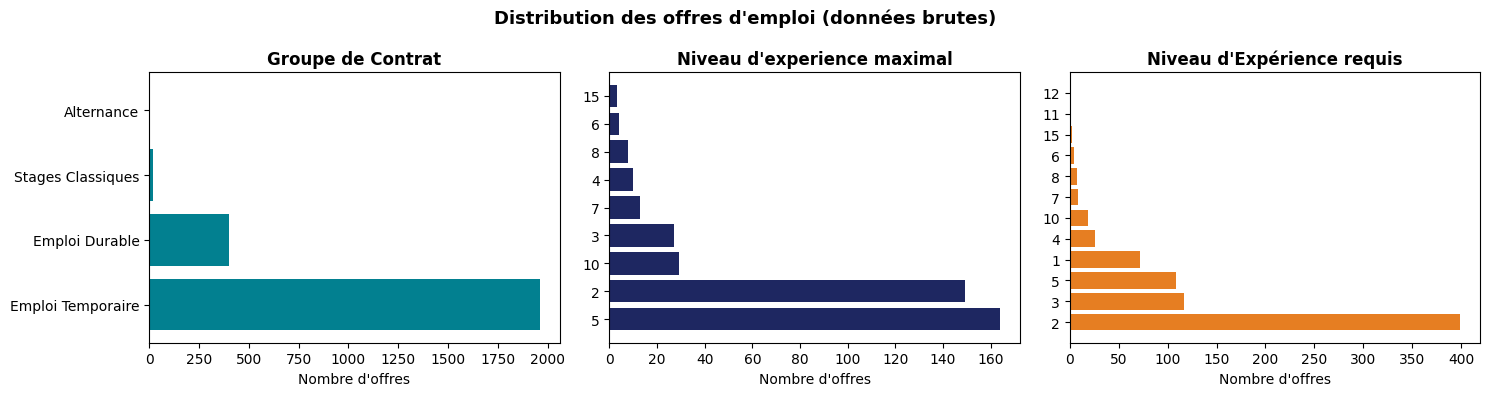

In [9]:
# Distribution par Source
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Groupe de Contrat
gc = df_offres['groupe_contrat'].value_counts()
axes[0].barh(gc.index, gc.values, color='#028090')
axes[0].set_title("Groupe de Contrat", fontweight='bold')
axes[0].set_xlabel("Nombre d'offres")

# Niveau d'experience maximal
ne = df_offres["exp_max_annees"].value_counts()
axes[1].barh(ne.index, ne.values, color='#1E2761')
axes[1].set_title("Niveau d'experience maximal", fontweight='bold')
axes[1].set_xlabel("Nombre d'offres")

# Niveau d'Expérience
nexp = df_offres["exp_min_annees"].value_counts()
axes[2].barh(nexp.index, nexp.values, color='#E67E22')
axes[2].set_title("Niveau d'Expérience requis", fontweight='bold')
axes[2].set_xlabel("Nombre d'offres")

plt.suptitle("Distribution des offres d'emploi (données brutes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Top secteurs d'activité (multi-valeurs explosées)

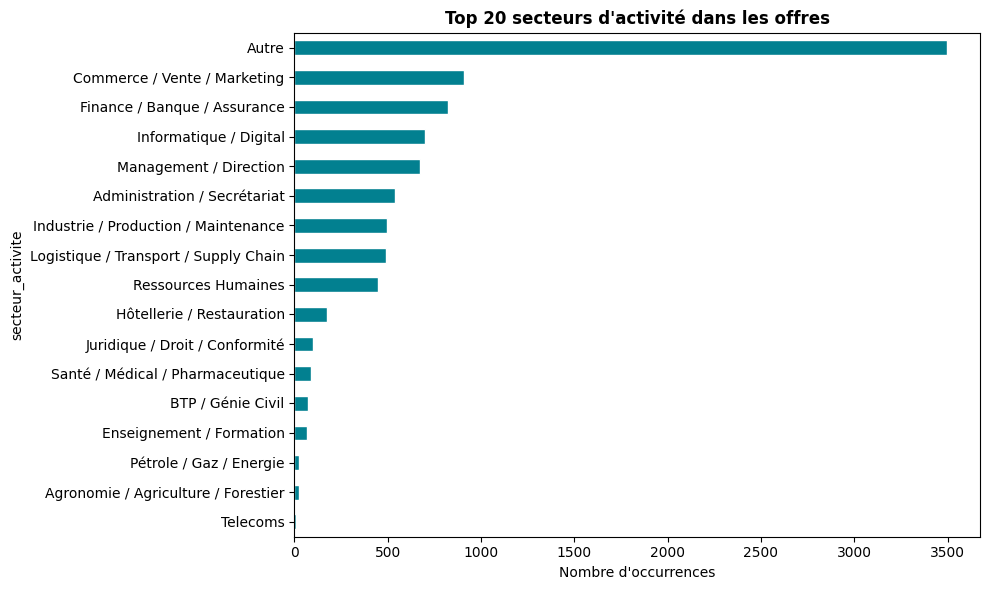

In [10]:
secteurs = (df_offres["secteur_activite"]
            .str.split(',').explode()
            .str.strip()
            .value_counts()
            .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
secteurs.sort_values().plot(kind='barh', ax=ax, color='#028090', edgecolor='white')
ax.set_title("Top 20 secteurs d'activité dans les offres", fontweight='bold')
ax.set_xlabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()


### Source de donnees

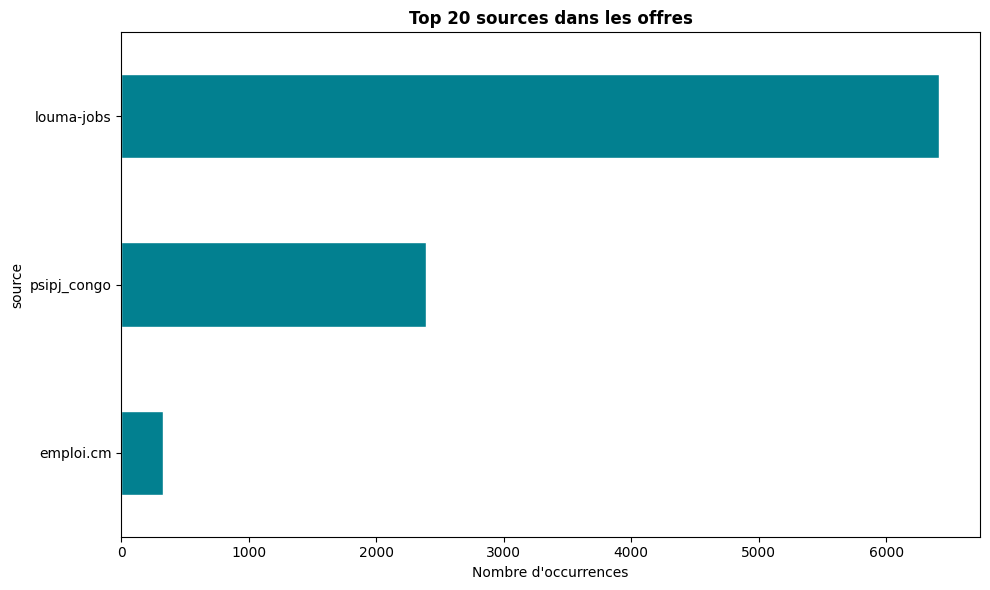

In [11]:
secteurs = (df_offres["source"]
            .str.split(',').explode()
            .str.strip()
            .value_counts()
            .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
secteurs.sort_values().plot(kind='barh', ax=ax, color='#028090', edgecolor='white')
ax.set_title("Top 20 sources dans les offres", fontweight='bold')
ax.set_xlabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

### Top villes de recrutement

In [ ]:
Index(['id_offre', 'titre_original', 'titre_normalise', 'secteur_activite',
       'entreprise', 'type_entreprise', 'ville_region', 'pays',
       'groupe_contrat', 'type_contrat', 'exp_min_annees', 'exp_max_annees',
       'niveau_etude', 'competences_cles', 'description_poste', 'missions',
       'profil_requis', 'info_employeur', 'source', 'lien_job',
       'date_publication', 'mois', 'trimestre'],
      dtype='str')

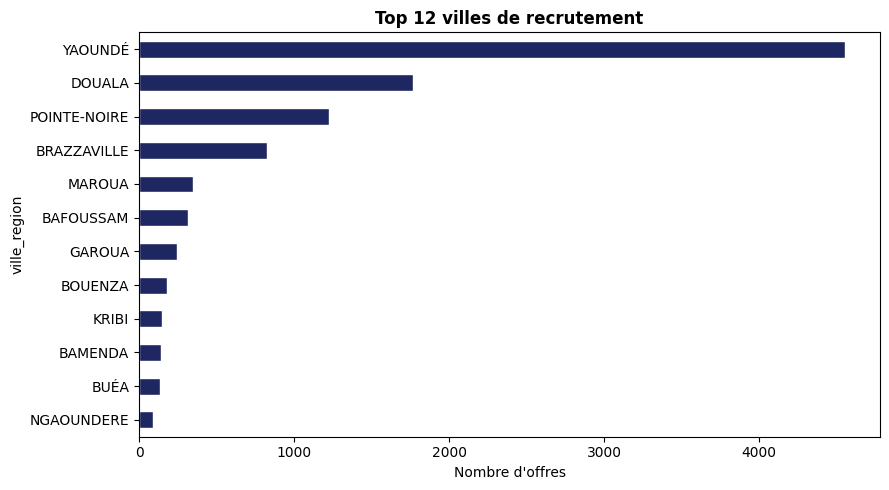

In [12]:
villes = (df_offres['ville_region']
          .str.split(',').explode()
          .str.strip()
          .str.upper()
          .value_counts()
          .head(12))

fig, ax = plt.subplots(figsize=(9, 5))
villes.sort_values().plot(kind='barh', ax=ax, color='#1E2761', edgecolor='white')
ax.set_title("Top 12 villes de recrutement", fontweight='bold')
ax.set_xlabel("Nombre d'offres")
plt.tight_layout()
plt.show()


## 3. Analyse des demandeurs d'emploi

In [16]:
rapport_cand = pd.DataFrame({
    'Colonne': df_cand.columns,
    'Non nuls': [df_cand[c].notna().sum() for c in df_cand.columns],
    'Remplissage (%)': [round(df_cand[c].notna().mean()*100, 1) for c in df_cand.columns],
    'Uniques': [df_cand[c].nunique() for c in df_cand.columns],
})
rapport_cand.style.background_gradient(subset=['Remplissage (%)'],cmap='RdYlGn')


,Colonne,Non nuls,Remplissage (%),Uniques
0,Matricule,1105,100.000000,1105
1,Age,1105,100.000000,47
2,Qualification,1105,100.000000,296
3,Secteur d'activité,1105,100.000000,44
4,Objectif,1105,100.000000,3
5,Diplome,1105,100.000000,22
6,Genre,1105,100.000000,2
7,niveau_etude,1105,100.000000,7
8,qualification_metier,1105,100.000000,226
9,secteur_metier,1105,100.000000,23


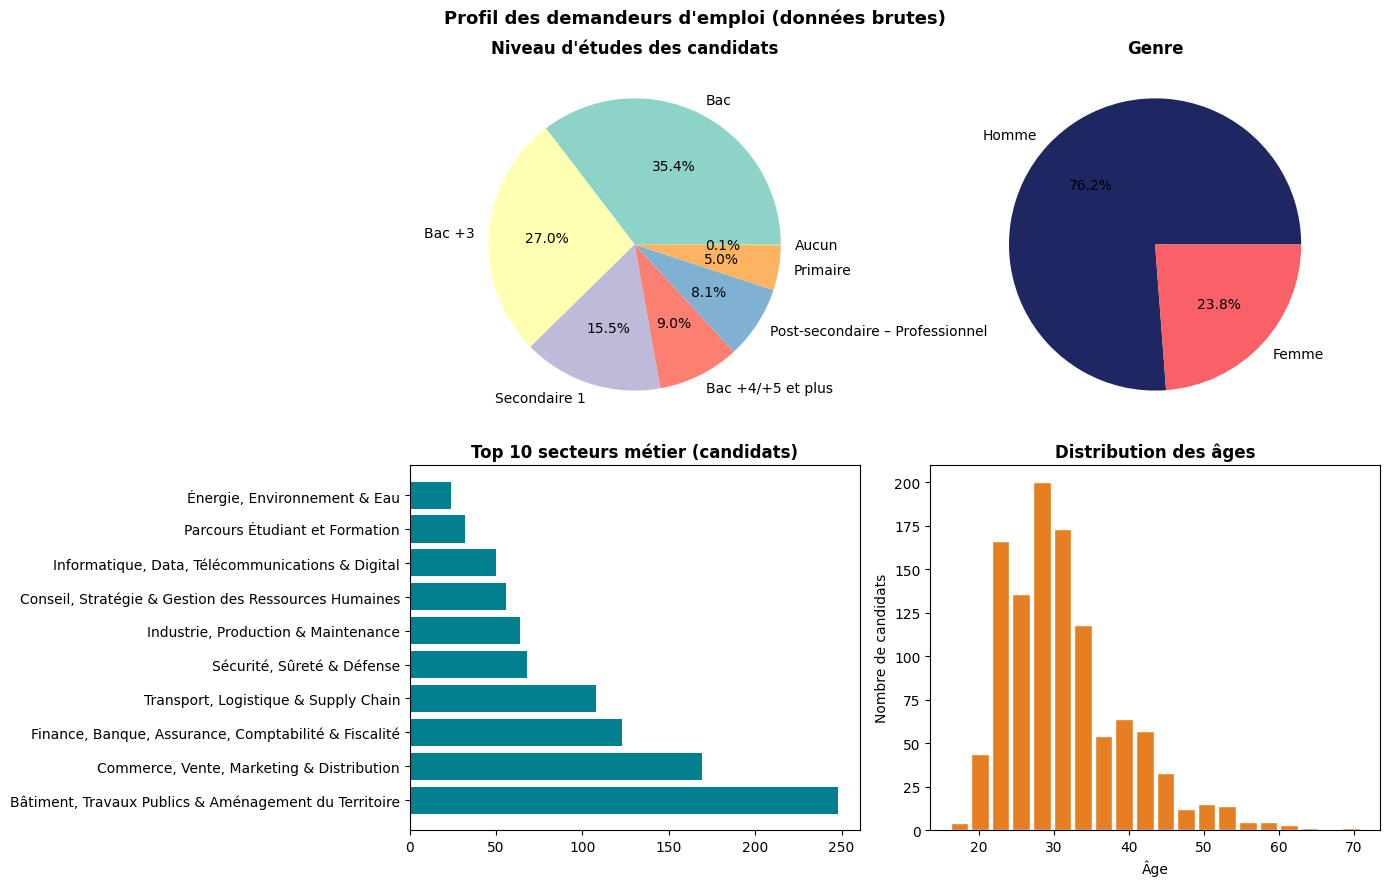

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Niveau d'Études
ne = df_cand['niveau_etude'].value_counts()
axes[0,0].pie(ne.values, labels=ne.index, autopct='%1.1f%%',
              colors=plt.cm.Set3.colors[:len(ne)])
axes[0,0].set_title("Niveau d'études des candidats", fontweight='bold')

# Genre
g = df_cand['Genre'].value_counts()
axes[0,1].pie(g.values, labels=g.index, autopct='%1.1f%%',
              colors=['#1E2761','#F96167'])
axes[0,1].set_title("Genre", fontweight='bold')

# Secteur métier (top 10)
sm = df_cand['secteur_metier'].value_counts().head(10)
axes[1,0].barh(sm.index, sm.values, color='#028090')
axes[1,0].set_title("Top 10 secteurs métier (candidats)", fontweight='bold')

# Distribution âge
df_cand['Age'].plot(kind='hist', bins=20, ax=axes[1,1],
                    color='#E67E22', edgecolor='white', rwidth=0.85)
axes[1,1].set_title("Distribution des âges", fontweight='bold')
axes[1,1].set_xlabel("Âge")
axes[1,1].set_ylabel("Nombre de candidats")

plt.suptitle("Profil des demandeurs d'emploi (données brutes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Mapping niveau_etude <> code NCF

In [18]:
from config import NIVEAU_ETUDES_CAND_TO_NCF

print("Mapping niveau_etude candidats <> code NCF (1-9) :")
for val, code in NIVEAU_ETUDES_CAND_TO_NCF.items():
    n = (df_cand['niveau_etude'] == val).sum()
    print(f"  NCF-{code}  {val:<35} <> {n} candidats")

print()
print("Valeurs Mobilité géographique :")
print(df_cand['Mobilité géographique'].value_counts().to_dict())
print(f"  → 91.7% 'Non déclaré' → seront mis à NULL dans le graphe")


Mapping niveau_etude candidats <> code NCF (1-9) :
  NCF-1  Aucun                               <> 1 candidats
  NCF-3  Primaire                            <> 55 candidats
  NCF-4  Secondaire 1                        <> 171 candidats
  NCF-5  Bac                                 <> 391 candidats
  NCF-6  Post-secondaire – Professionnel     <> 89 candidats
  NCF-7  Bac +3                              <> 298 candidats
  NCF-8  Bac +4/+5 et plus                   <> 100 candidats

Valeurs Mobilité géographique :
{'Non déclaré': 1012, 'Non': 91, 'Oui': 2}
  → 91.7% 'Non déclaré' → seront mis à NULL dans le graphe


## 4. Analyse des référentiels MEPC, NCF, ESCO

In [19]:
print("=== MEPC <>” Structure hiérarchique ===")
for sheet, df in mepc_raw.items():
    print(f"  [{sheet}] : {len(df)} entrées | colonnes: {list(df.columns)}")

print()
print("=== NCF <>” Structure hiérarchique ===")
for sheet, df in ncf_raw.items():
    print(f"  [{sheet}] : {len(df)} entrées | colonnes: {list(df.columns)}")


=== MEPC <>” Structure hiérarchique ===
  [Grands Groupes] : 8 entrées | colonnes: ['Code', 'Intitulé', 'Notes Explicatives (MEPC)', 'Codes CITP rev.4']
  [Sous-Groupes] : 44 entrées | colonnes: ['Code', 'Intitulé', 'Notes Explicatives (MEPC)', 'Codes CITP rev.4', 'Code Grand Groupe']
  [Groupes de Base] : 209 entrées | colonnes: ['Code', 'Intitulé', 'Notes Explicatives (MEPC)', 'Codes CITP rev.4', 'Code Sous-Groupe', 'Code Grand Groupe']

=== NCF <>” Structure hiérarchique ===
  [Niveaux de Formation] : 9 entrées | colonnes: ['Code', 'Intitulé', 'Notes explicatives (NCF)']
  [Grands Domaines] : 10 entrées | colonnes: ['Code', 'Intitulé', 'Explication (NCF)']
  [Domaines Spécialisés] : 31 entrées | colonnes: ['Code', 'Intitulé', 'Explication (NCF)', 'Code Grand Domaine']
  [Domaines Détaillés] : 201 entrées | colonnes: ['Code', 'Intitulé', 'Explication (NCF)', 'Code Dom. Spécialisé', 'Code Grand Domaine']


### Visualisation hiérarchie MEPC

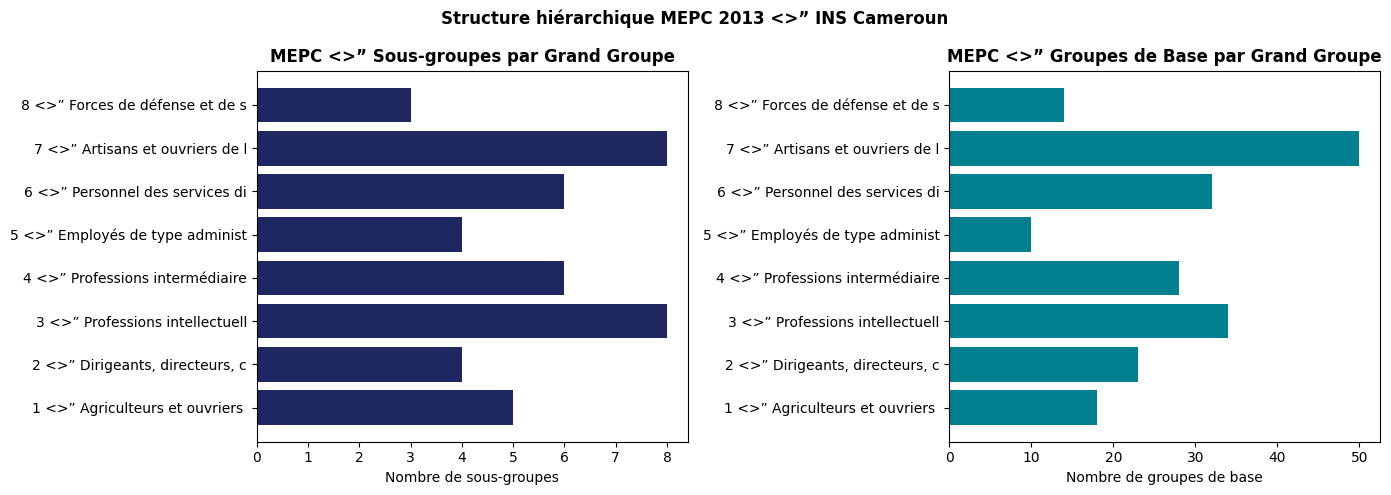

In [20]:
mepc_grands = mepc_raw['Grands Groupes']
mepc_sous   = mepc_raw['Sous-Groupes']
mepc_base   = mepc_raw['Groupes de Base']

# Nombre de sous-groupes par grand groupe
n_sous = mepc_sous.groupby('Code Grand Groupe').size().reset_index(name='N_sous_groupes')
n_base = mepc_base.groupby('Code Grand Groupe').size().reset_index(name='N_groupes_base')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# N sous-groupes
labels_g = [f"{r['Code']} <>” {r['Intitulé'][:25]}" for _, r in mepc_grands.iterrows()]
axes[0].barh(labels_g, n_sous['N_sous_groupes'].values, color='#1E2761')
axes[0].set_title("MEPC <>” Sous-groupes par Grand Groupe", fontweight='bold')
axes[0].set_xlabel("Nombre de sous-groupes")

# N groupes de base
axes[1].barh(labels_g, n_base['N_groupes_base'].values, color='#028090')
axes[1].set_title("MEPC <>” Groupes de Base par Grand Groupe", fontweight='bold')
axes[1].set_xlabel("Nombre de groupes de base")

plt.suptitle("Structure hiérarchique MEPC 2013 <>” INS Cameroun", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Pont MEPC <> ESCO via ISCO-08

In [21]:
# Analyse des codes CITP disponibles dans la MEPC
codes_citp = (mepc_base['Codes CITP rev.4']
              .dropna()
              .str.replace('/', ',')
              .str.split(',')
              .explode()
              .str.strip()
              .value_counts())
print(f"Codes CITP uniques dans MEPC : {codes_citp.nunique()}")
print(f"Groupes de base MEPC avec codes CITP : {mepc_base['Codes CITP rev.4'].notna().sum()} / {len(mepc_base)}")
print()
print("Extrait :")
print(mepc_base[['Code', 'Intitulé', 'Codes CITP rev.4']].head(8).to_string(index=False))


Codes CITP uniques dans MEPC : 6
Groupes de base MEPC avec codes CITP : 209 / 209

Extrait :
 Code                                                           Intitulé Codes CITP rev.4
 1101                                              Exploitants agricoles       6114, 6310
 1102                                                 Ouvriers agricoles       6114, 6310
 1201                                                 Eleveurs de bovins       6121, 6320
 1202                                       Eleveurs de caprins et ovins       6129, 6330
 1203                                                Eleveurs de porcins       6129, 6330
 1204                               Eleveurs de volailles et des oiseaux       6129, 6330
 1205 Autres éleveurs (apiculteurs, aviculteurs, aulacodiculteurs, etc.) 6122, 6123, 6129
 1206                            Bergers et autres ouvriers de l'élevage             6130


## 5. Exécution du pipeline ETL

In [2]:
# Exécution complète du pipeline ETL
import run_etl
results = run_etl.run_all()


2026-05-07 09:19:14,160 | INFO | ======================================================================
2026-05-07 09:19:14,161 | INFO | PIPELINE ETL COMPLET — SYSTÈME RECOMMANDATION EMPLOI-CAMEROUN
2026-05-07 09:19:14,162 | INFO | ======================================================================
2026-05-07 09:19:14,163 | INFO | 
[ÉTAPE 1/4] Normalisation des offres d'emploi
2026-05-07 09:19:14,164 | INFO | ============================================================
2026-05-07 09:19:14,165 | INFO | PIPELINE ETL — OFFRES D'EMPLOI
2026-05-07 09:19:14,166 | INFO | ============================================================
2026-05-07 09:19:14,167 | INFO | Chargement offres : D:\DATA SCIENCES\PRE-TEST-SYSTEME-DE-RECOMMANDATION\data\raw\offres.xlsx


2026-05-07 09:19:15,861 | INFO |   → 8695 lignes, 14 colonnes
2026-05-07 09:19:16,457 | INFO | [1/7] Nettoyage de base terminé
2026-05-07 09:19:16,476 | INFO | Déduplication: 8695 -> 7861 lignes (-834)
2026-05-07 09:19:16,477 | INFO | [2/7] Déduplication terminée
2026-05-07 09:19:17,462 | INFO |   Détails nettoyés : 2702 / 7861 non vides
2026-05-07 09:19:17,463 | INFO | [3/7] Nettoyage détails annonce terminé
2026-05-07 09:19:17,960 | INFO |   Villes : 7861 précisées
2026-05-07 09:19:17,961 | INFO |   Secteurs : 7861 précisés
2026-05-07 09:19:17,962 | INFO | [4/7] Explosion multi-valeurs terminée
2026-05-07 09:19:17,981 | INFO | [5/7] Mapping catégoriels terminé
2026-05-07 09:19:18,013 | INFO | [6/7] Schéma finalisé
2026-05-07 09:19:18,425 | INFO |   Paires FT éligibles: 3302 / 7861
2026-05-07 09:19:18,426 | INFO | [7/7] Textes d'embedding construits
2026-05-07 09:19:18,542 | INFO | Sauvegardé → D:\DATA SCIENCES\PRE-TEST-SYSTEME-DE-RECOMMANDATION\data\processed\offres_normalized.parque

## 6. Validation des données traitées

In [3]:
df_off_proc  = pd.read_parquet(DATA_PROC / 'offres_normalized.parquet')
df_cand_proc = pd.read_parquet(DATA_PROC / 'candidats_normalized.parquet')

print("=== OFFRES NORMALISÉES ===")
print(f"Shape : {df_off_proc.shape}")
print(f"Colonnes : {list(df_off_proc.columns)}")
print()
print("Apercu NaN par colonne clé :")
key_cols = ['titre_poste', 'ncf_niveau_code', 'secteur_principal',
            'ville_principale', 'experience_min_ans', 'ft_eligible']
for col in key_cols:
    if col in df_off_proc.columns:
        pct_null = df_off_proc[col].isna().mean() * 100
        print(f"  {col:<30} : {pct_null:.1f}% manquants")


=== OFFRES NORMALISÉES ===
Shape : (7861, 30)
Colonnes : ['offre_id', 'source', 'titre_poste', 'employeur', 'type_entreprise_norm', 'pays', 'ville_principale', 'villes_list', 'secteur_principal', 'secteurs_list', 'groupe_contrat_norm', 'type_contrat_norm', 'ncf_niveau_code', 'niveau_etudes_raw', 'experience_min_ans', 'niveau_experience_raw', 'skills_list', 'skills_raw', 'details_clean', 'details_truncated', 'details_raw', 'lien_reference', 'groupe_contrat_raw', 'type_contrat_raw', 'secteur_activite_raw', 'ville_region_raw', 'type_entreprise_raw', 'text_to_embed', 'metadata_str', 'ft_eligible']

Apercu NaN par colonne clé :
  titre_poste                    : 0.0% manquants
  ncf_niveau_code                : 36.2% manquants
  secteur_principal              : 0.0% manquants
  ville_principale               : 0.0% manquants
  experience_min_ans             : 39.9% manquants
  ft_eligible                    : 0.0% manquants


2026-05-07 09:21:30,780 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 09:21:30,782 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 09:21:30,791 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 09:21:30,792 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


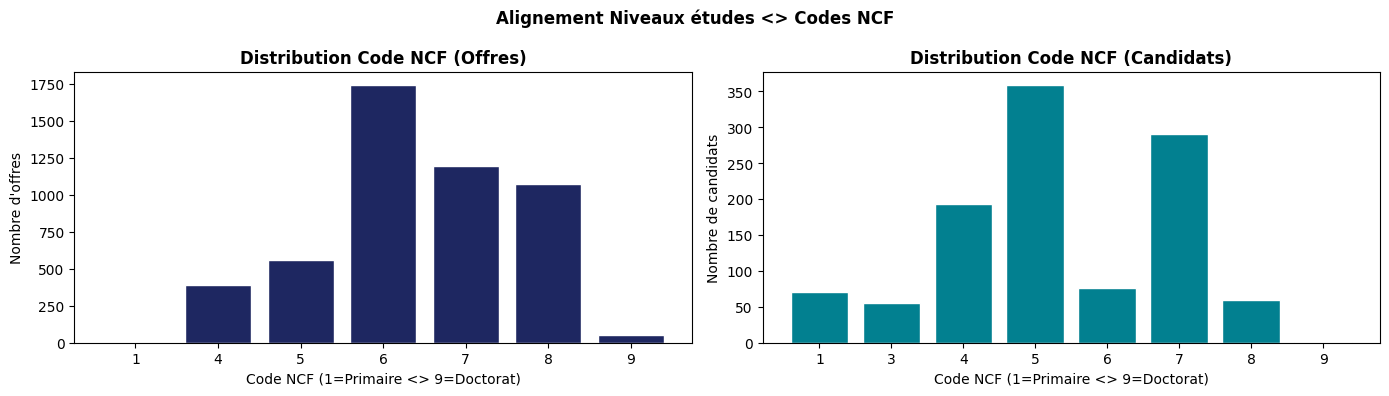

In [4]:
# Distribution NCF dans les offres
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ncf_dist = df_off_proc['ncf_niveau_code'].value_counts().sort_index()
axes[0].bar(ncf_dist.index.astype(str), ncf_dist.values, color='#1E2761', edgecolor='white')
axes[0].set_title("Distribution Code NCF (Offres)", fontweight='bold')
axes[0].set_xlabel("Code NCF (1=Primaire <> 9=Doctorat)")
axes[0].set_ylabel("Nombre d'offres")

ncf_cand = df_cand_proc['ncf_niveau_final'].value_counts().sort_index()
axes[1].bar(ncf_cand.index.astype(str), ncf_cand.values, color='#028090', edgecolor='white')
axes[1].set_title("Distribution Code NCF (Candidats)", fontweight='bold')
axes[1].set_xlabel("Code NCF (1=Primaire <> 9=Doctorat)")
axes[1].set_ylabel("Nombre de candidats")

plt.suptitle("Alignement Niveaux études <> Codes NCF", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [5]:
# Analyse des paires fine-tuning
with open(DATA_FT / 'pairs_metadata.json') as f:
    meta = json.load(f)

print("=== PAIRES FINE-TUNING SENTENCETRANSFORMER ===")
print(f"Total paires         : {meta['total_paires']:,}")
print(f"Train                : {meta['n_train']:,}")
print(f"Validation           : {meta['n_val']:,}")
print(f"Test                 : {meta['n_test']:,}")
print()
print(f"Longueur moy sentence1 (metadata) : {meta['stats_longueur']['s1_mean']:.0f} chars")
print(f"Longueur moy sentence2 (corpus)   : {meta['stats_longueur']['s2_mean']:.0f} chars")
print()
print("Exemple paire :")
import json as _json
with open(DATA_FT / 'pairs_train.jsonl') as f:
    ex = _json.loads(f.readline())
print("  sentence1:", ex['sentence1'][:120])
print("  sentence2:", ex['sentence2'][:120])


=== PAIRES FINE-TUNING SENTENCETRANSFORMER ===
Total paires         : 3,302
Train                : 2,321
Validation           : 508
Test                 : 473

Longueur moy sentence1 (metadata) : 159 chars
Longueur moy sentence2 (corpus)   : 559 chars

Exemple paire :
  sentence1: Poste: ChargÃ©(e) des Ressources Humaines H/F - Douala | Secteur: ActivitÃ©s Associatives | Contrat: CDD | Ã‰tudes: Lice
  sentence2: CompÃ©tences requises : ActivitÃ©s associatives ChargÃ©(e) des Ressources Humaines H/F - Douala

Lâ€™Institut EuropÃ©en 


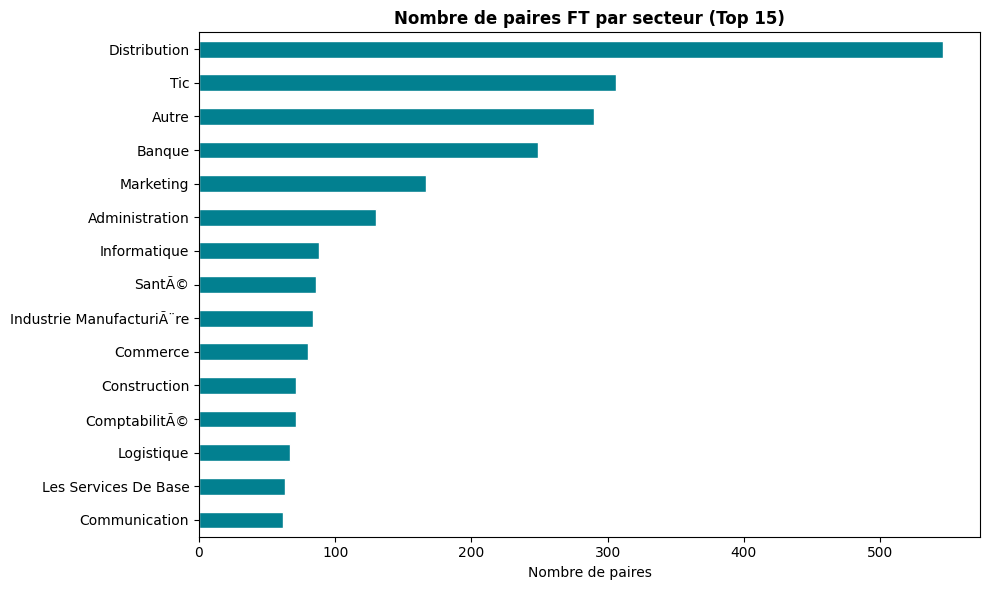

In [6]:
# Distribution des paires par secteur
n_pairs_secteur = pd.Series(meta['distribution_secteurs']).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
n_pairs_secteur.sort_values().plot(kind='barh', ax=ax, color='#028090', edgecolor='white')
ax.set_title("Nombre de paires FT par secteur (Top 15)", fontweight='bold')
ax.set_xlabel("Nombre de paires")
plt.tight_layout()
plt.show()


## 7. Synthèse du preprocessing

In [7]:
print("=" * 60)
print("SYNTHESE DU MODULE ETL")
print("=" * 60)

print()
print("DONNEES BRUTES")
print(f"  Offres  brutes    : 8 695 lignes")
print(f"  Candidats bruts   : 1 105 lignes")

print()
print("DONNEES NORMALISEES")
print(f"  Offres normalisees  : {len(df_off_proc):,} offres")
print(f"  Candidats normalises: {len(df_cand_proc):,} candidats")

print()
print("PROBLEMES TRAITEES")
print(f"  Doublons supprimés       : 834")
print(f"  ✓ Boilerplate scraping nettoyé")
print(f"  ✓ Multi-valeurs explosées  : villes, secteurs, compétences")
print(f"  ✓ Mapping Niveau Études → NCF (1-9)")
print(f"  ✓ Mapping Diplôme → NCF (résolution par priorité)")
print(f"  ✓ 'Non déclaré' → NULL")
print(f"  ✓ Mobilité géographique normalisée")
print(f"  ✓ Types de contrat harmonisés")
print(f"  ✓ Mapping MEPC ↔ ESCO via ISCO-08 (19 980 correspondances)")

print()
print("📚 PAIRES FINE-TUNING ST")
print(f"  Train : {meta['n_train']:,} paires (70%)")
print(f"  Val   : {meta['n_val']:,} paires (15%)")
print(f"  Test  : {meta['n_test']:,} paires (15%)")
print(f"  Format : JSONL — InputExample sentence-transformers")
print(f"  Modèle cible : all-MiniLM-L6-v2")
print(f"  Perte : MultipleNegativesRankingLoss")

print()
print("→ Prochaine étape : src/02_finetune_st/train_sentence_transformer.py")


SYNTHESE DU MODULE ETL

DONNEES BRUTES
  Offres  brutes    : 8 695 lignes
  Candidats bruts   : 1 105 lignes

DONNEES NORMALISEES
  Offres normalisees  : 7,861 offres
  Candidats normalises: 1,105 candidats

PROBLEMES TRAITEES
  Doublons supprimés       : 834
  ✓ Boilerplate scraping nettoyé
  ✓ Multi-valeurs explosées  : villes, secteurs, compétences
  ✓ Mapping Niveau Études → NCF (1-9)
  ✓ Mapping Diplôme → NCF (résolution par priorité)
  ✓ 'Non déclaré' → NULL
  ✓ Mobilité géographique normalisée
  ✓ Types de contrat harmonisés
  ✓ Mapping MEPC ↔ ESCO via ISCO-08 (19 980 correspondances)

📚 PAIRES FINE-TUNING ST
  Train : 2,321 paires (70%)
  Val   : 508 paires (15%)
  Test  : 473 paires (15%)
  Format : JSONL — InputExample sentence-transformers
  Modèle cible : all-MiniLM-L6-v2
  Perte : MultipleNegativesRankingLoss

→ Prochaine étape : src/02_finetune_st/train_sentence_transformer.py
